<a href="https://colab.research.google.com/github/akshaya-bharadhwaj/nec-xray-lightweight-cnn/blob/main/CHOC_NEC_Classification_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GOSH NEC Reproducible Lightweight CNN Experiments

This notebook is the clean final analysis pipeline for the GOSH NEC 3-class abdominal X-ray task.

### Experimental rules
- A locked, stratified sample of **100 patients** is created once and then reused. It is never used for model selection.
- Train/validation splitting is patient-level and fixed across all experiments.
- Every comparison uses the same preprocessing, optimizer, training budget, early stopping, split, and three seeds: **42, 123, 7**.
- Randomness is reset before every run so model initialization, DataLoader shuffling, and stochastic augmentation are reproducible.
- The depth sweep is used to select the CNN depth. Augmentation experiments then use that selected depth.
- The locked test set is evaluated only after the final configuration has been selected.

**Primary selection metric:** mean validation Macro-F1 across seeds. Macro ROC-AUC is the secondary metric.


## 1. Setup

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path
import os, re, zipfile, shutil, copy, time, random, math, json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score
from sklearn.preprocessing import label_binarize

SPLIT_SEED = 42
SEEDS_TO_TRY = [42, 123, 7]
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 8
BATCH_SIZE = 16
TARGET_HEIGHT = 320
TARGET_WIDTH = 224
DEPTHS_TO_TEST = [1, 2, 4, 8, 16]

# User-provided GOSH NEC dataset location
ZIP_PATH = Path("/content/drive/MyDrive/GOSH_NEC/GOSH_NEC.zip")

# Temporary working directory in the Colab runtime
EXTRACT_PATH = Path("/content/GOSH_NEC")

# User's own output directories
RESULTS_DIR = Path("/content/drive/MyDrive/GOSH_NEC/results")
SPLITS_DIR = Path("/content/drive/MyDrive/GOSH_NEC/splits")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Experiment seeds:", SEEDS_TO_TRY)


Using device: cuda
Experiment seeds: [42, 123, 7]


## 2. Extract dataset (same zip/path as the earlier notebooks)

In [ ]:
# Extract only if needed. Keeping the existing directory avoids unnecessary re-extraction.
FORCE_REEXTRACT = False

if FORCE_REEXTRACT or not EXTRACT_PATH.exists():
    if EXTRACT_PATH.exists():
        shutil.rmtree(EXTRACT_PATH)
    EXTRACT_PATH.mkdir(parents=True, exist_ok=True)

    if not ZIP_PATH.exists():
        raise FileNotFoundError(f"Dataset zip not found: {ZIP_PATH}")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("Extraction complete.")
else:
    print("Using existing extracted dataset:", EXTRACT_PATH)


Extraction complete.


## 3. Image-level dataframe

In [ ]:
CLASS_FOLDERS = ["Mn", "Np", "Sn"]

def find_dataset_root(start_path):
    start_path = Path(start_path)
    if all((start_path / folder).is_dir() for folder in CLASS_FOLDERS):
        return start_path
    for path in start_path.rglob("*"):
        if path.is_dir():
            if all((path / folder).is_dir() for folder in CLASS_FOLDERS):
                return path
    return None

DATASET_PATH = find_dataset_root(EXTRACT_PATH)
if DATASET_PATH is None:
    raise FileNotFoundError(f"Could not find {CLASS_FOLDERS} inside {EXTRACT_PATH}")
print("Dataset found at:", DATASET_PATH)

Dataset found at: /content/GOSH_NEC/GOSH_NEC


In [ ]:
CLASS_NAMES = {"Mn": "Medical NEC", "Np": "No Pathology", "Sn": "Surgical NEC"}
LABEL_MAP = {"Mn": 0, "Np": 1, "Sn": 2}
IMAGE_EXTENTIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

records = []
for class_folder in CLASS_FOLDERS:
    folder_path = DATASET_PATH / class_folder
    image_files = sorted([f for f in folder_path.iterdir() if f.suffix.lower() in IMAGE_EXTENTIONS])
    for filepath in image_files:
        records.append({
            "filepath": str(filepath), "filename": filepath.name,
            "class_code": class_folder, "class_name": CLASS_NAMES[class_folder],
            "label": LABEL_MAP[class_folder]
        })

df = pd.DataFrame(records)
print(f"Total images found: {len(df)}")

Total images found: 1149


In [ ]:
def parse_filename(filename):
    stem = Path(filename).stem
    group_match = re.match(r"^(Mn|Np|Sn)(\d{4})", stem)
    if group_match:
        inferred_group_id = group_match.group(1) + group_match.group(2)
    else:
        inferred_group_id = None
    return pd.Series({"inferred_group_id": inferred_group_id})

df = pd.concat([df, df["filename"].apply(parse_filename)], axis=1)

# Filter out unusably small images, same threshold as the original EDA
widths_heights = []
for fp in df["filepath"]:
    with Image.open(fp) as im:
        widths_heights.append(im.size)
df["width"] = [w for w, h in widths_heights]
df["height"] = [h for w, h in widths_heights]
df["include_in_model"] = (df["width"] >= 100) & (df["height"] >= 100)
model_df = df[df["include_in_model"]].copy()

print(f"Images used for modeling: {len(model_df)} (excluded {len(df) - len(model_df)})")
print(f"Unique patients: {model_df['inferred_group_id'].nunique()}")

Images used for modeling: 1148 (excluded 1)
Unique patients: 388


## 4. Build the locked test set: 100 patients, random, stratified by class

A pure random draw of 100 out of ~388 patients could, by chance, end up with very few patients of one class (small-sample variance). Stratifying by class proportionally avoids that risk while still being a random sample within each class. If a literal unstratified random sample is preferred instead, that's a one-line change.

**This test set is built once, saved to its own file, and should not be loaded again except for final model evaluation.**

In [ ]:
TEST_PATIENT_COUNT = 100

# IMPORTANT: this file is the persistent identity of the locked test set.
# If it exists, NEVER redraw the test patients.
LOCKED_TEST_IDS_PATH = SPLITS_DIR / "gosh_nec_LOCKED_test_100patients_ids.txt"
LOCKED_TEST_METADATA_PATH = SPLITS_DIR / "gosh_nec_LOCKED_test_100patients.csv"

patient_df = (
    model_df[["inferred_group_id", "class_code"]]
    .drop_duplicates(subset="inferred_group_id")
    .reset_index(drop=True)
)

def stratified_patient_sample(patient_df, class_col, n_total, seed):
    rng = np.random.RandomState(seed)
    counts = patient_df[class_col].value_counts()
    proportions = counts / counts.sum()
    quotas = (proportions * n_total).round().astype(int).to_dict()

    # Correct rounding so quotas sum exactly to n_total.
    while sum(quotas.values()) < n_total:
        cls = max(quotas, key=lambda c: proportions[c] - quotas[c] / n_total)
        quotas[cls] += 1
    while sum(quotas.values()) > n_total:
        eligible = [c for c in quotas if quotas[c] > 1]
        cls = max(eligible, key=lambda c: quotas[c] / n_total - proportions[c])
        quotas[cls] -= 1

    sampled = []
    for cls, quota in quotas.items():
        pool = patient_df.loc[patient_df[class_col] == cls, "inferred_group_id"].values
        sampled.extend(rng.choice(pool, size=quota, replace=False).tolist())

    rng.shuffle(sampled)
    return sampled, quotas

if LOCKED_TEST_IDS_PATH.exists():
    test_patient_ids = LOCKED_TEST_IDS_PATH.read_text().splitlines()
    print("Loaded existing locked test patient IDs.")
else:
    test_patient_ids, test_quotas = stratified_patient_sample(
        patient_df, "class_code", TEST_PATIENT_COUNT, SPLIT_SEED
    )
    LOCKED_TEST_IDS_PATH.write_text("\n".join(test_patient_ids))
    print("Created and saved locked test patient IDs.")
    print("Class quotas:", test_quotas)

if len(set(test_patient_ids)) != TEST_PATIENT_COUNT:
    raise ValueError("Locked test set must contain exactly 100 unique patients.")

test_df = model_df[model_df["inferred_group_id"].isin(test_patient_ids)].copy()
pool_df = model_df[~model_df["inferred_group_id"].isin(test_patient_ids)].copy()

test_df.to_csv(LOCKED_TEST_METADATA_PATH, index=False)

print(f"Locked test: {len(test_df)} images / {test_df['inferred_group_id'].nunique()} patients")
print(test_df["class_code"].value_counts().sort_index())
print(f"Experiment pool: {len(pool_df)} images / {pool_df['inferred_group_id'].nunique()} patients")

assert not (set(test_df["inferred_group_id"]) & set(pool_df["inferred_group_id"]))


Loaded existing locked test patient IDs.
Locked test: 324 images / 100 patients
class_code
Mn     82
Np     85
Sn    157
Name: count, dtype: int64
Experiment pool: 824 images / 288 patients


In [ ]:
# The stratified sampling helper is defined in the previous cell.
# No second sampling operation is performed here.
print("Test split is fixed; no redraw performed.")


Test split is fixed; no redraw performed.


In [ ]:
print("Locked test metadata:", LOCKED_TEST_METADATA_PATH)
print("The locked test set remains unopened for model selection.")


Locked test metadata: /content/drive/MyDrive/CHOC/splits/gosh_nec_LOCKED_test_100patients.csv
The locked test set remains unopened for model selection.


## 5. Create/load the fixed patient-level train/validation split

The split is created once and then reused. This prevents later notebook runs from changing the validation set.


In [ ]:
TRAINVAL_SPLIT_PATH = SPLITS_DIR / "gosh_nec_trainval_FIXED.csv"

if TRAINVAL_SPLIT_PATH.exists():
    split_df = pd.read_csv(TRAINVAL_SPLIT_PATH)
    train_df = split_df[split_df["split"] == "train"].copy()
    val_df = split_df[split_df["split"] == "validation"].copy()
    print("Loaded existing fixed train/validation split.")
else:
    pool_patient_df = (
        pool_df[["inferred_group_id", "class_code"]]
        .drop_duplicates(subset="inferred_group_id")
        .reset_index(drop=True)
    )
    n_val = round(len(pool_patient_df) * 0.20)
    val_patient_ids, val_quotas = stratified_patient_sample(
        pool_patient_df, "class_code", n_val, SPLIT_SEED + 1
    )
    val_df = pool_df[pool_df["inferred_group_id"].isin(val_patient_ids)].copy()
    train_df = pool_df[~pool_df["inferred_group_id"].isin(val_patient_ids)].copy()

    split_df = pd.concat([
        train_df.assign(split="train"),
        val_df.assign(split="validation")
    ], ignore_index=True)
    split_df.to_csv(TRAINVAL_SPLIT_PATH, index=False)
    print("Created and saved fixed train/validation split.")

train_patients = set(train_df["inferred_group_id"])
val_patients = set(val_df["inferred_group_id"])
test_patients = set(test_df["inferred_group_id"])

print(f"Train: {len(train_df)} images / {len(train_patients)} patients")
print(train_df["class_code"].value_counts().sort_index())
print()
print(f"Validation: {len(val_df)} images / {len(val_patients)} patients")
print(val_df["class_code"].value_counts().sort_index())

assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)


Loaded existing fixed train/validation split.
Train: 663 images / 230 patients
class_code
Mn    202
Np    268
Sn    193
Name: count, dtype: int64

Validation: 161 images / 58 patients
class_code
Mn    39
Np    51
Sn    71
Name: count, dtype: int64


## 6. Image Preprocessing

In [ ]:
TARGET_HEIGHT = 320
TARGET_WIDTH = 224

def resize_and_pad(image, target_height=TARGET_HEIGHT, target_width=TARGET_WIDTH):
    image = image.convert("L")
    original_width, original_height = image.size
    scale = min(target_width / original_width, target_height / original_height)
    new_width = round(original_width * scale)
    new_height = round(original_height * scale)
    image = image.resize((new_width, new_height), Image.Resampling.LANCZOS)
    pad_left = (target_width - new_width) // 2
    pad_right = target_width - new_width - pad_left
    pad_top = (target_height - new_height) // 2
    pad_bottom = target_height - new_height - pad_top
    image = ImageOps.expand(image, border=(pad_left, pad_top, pad_right, pad_bottom), fill=0)
    return image

In [ ]:
# Recompute normalization stats on THIS train set (composition changed from the earlier split)
pixel_sum, pixel_squared_sum, pixel_count = 0.0, 0.0, 0

for filepath in train_df["filepath"]:
    image = resize_and_pad(Image.open(filepath))
    arr = np.asarray(image, dtype=np.float32) / 255.0
    pixel_sum += arr.sum()
    pixel_squared_sum += (arr ** 2).sum()
    pixel_count += arr.size

train_mean = pixel_sum / pixel_count
train_variance = (pixel_squared_sum / pixel_count) - (train_mean ** 2)
train_std = np.sqrt(max(train_variance, 1e-12))

print(f"Training mean: {train_mean:.6f}")
print(f"Training std:  {train_std:.6f}")

base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[train_mean], std=[train_std])
])

Training mean: 0.384729
Training std:  0.322545


In [ ]:
class GOSHNECDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = resize_and_pad(Image.open(row["filepath"]))
        if self.transform:
            image = self.transform(image)
        return image, int(row["label"])


BATCH_SIZE = 16

train_dataset = GOSHNECDataset(train_df, transform=base_transform)
val_dataset = GOSHNECDataset(val_df, transform=base_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Train:", len(train_dataset), "| Val:", len(val_dataset))
class_names = ["Mn", "Np", "Sn"]

Train: 663 | Val: 161


## 7. Configurable lightweight CNN builder

One function builds all five depths, so architectures differ *only* in depth, not in design philosophy.

**Design rules:**
- Conv layers are grouped into stages of up to 2 convs each
- Channel width per stage follows the sequence **8 → 16 → 32** (2³, 2⁴, 2⁵), and stays at 32 for any additional stages beyond the third. This keeps the depth sweep a controlled experiment where width is capped consistently, not confounded with depth.
- Pooling (`MaxPool2d`) happens after each stage, **up to a maximum of 5 pooling operations**. Beyond that, additional stages keep the same spatial resolution (5 halvings of a ~224-320px input reaches a sensible minimum size, going further would collapse the feature map before the network finishes).

In [ ]:
import math

MAX_POOLS = 5
CHANNEL_SEQUENCE = [8, 16, 32]  # 2^3, 2^4, 2^5 — capped at 32 for deeper networks

def get_stage_channels(stage_idx):
    if stage_idx < len(CHANNEL_SEQUENCE):
        return CHANNEL_SEQUENCE[stage_idx]
    return CHANNEL_SEQUENCE[-1]


class ConfigurableLightweightCNN(nn.Module):
    def __init__(self, n_conv_layers, num_classes=3, in_channels=1):
        super().__init__()
        assert n_conv_layers >= 1

        n_stages = math.ceil(n_conv_layers / 2)
        remaining_convs = n_conv_layers
        stages = []
        prev_channels = in_channels
        pools_used = 0

        for stage_idx in range(n_stages):
            convs_this_stage = min(2, remaining_convs)
            out_channels = get_stage_channels(stage_idx)

            layers = []
            for conv_i in range(convs_this_stage):
                layers.append(nn.Conv2d(prev_channels, out_channels, kernel_size=3, padding=1))
                layers.append(nn.BatchNorm2d(out_channels))
                layers.append(nn.ReLU(inplace=True))
                prev_channels = out_channels

            if pools_used < MAX_POOLS:
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
                pools_used += 1

            stages.append(nn.Sequential(*layers))
            remaining_convs -= convs_this_stage

        self.stages = nn.Sequential(*stages)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=0.3)
        self.classifier = nn.Linear(prev_channels, num_classes)

        self.n_conv_layers = n_conv_layers
        self.final_channels = prev_channels

    def forward(self, x):
        x = self.stages(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.classifier(x)

In [ ]:
# Sanity check: build each depth, confirm layer count and check parameter counts / output shape
DEPTHS_TO_TEST = [1, 2, 4, 8, 16]  # 2^0, 2^1, 2^2, 2^3, 2^4

dummy_input = torch.zeros(1, 1, TARGET_HEIGHT, TARGET_WIDTH)

for depth in DEPTHS_TO_TEST:
    model = ConfigurableLightweightCNN(n_conv_layers=depth)
    n_params = sum(p.numel() for p in model.parameters())
    with torch.no_grad():
        out = model(dummy_input)
    print(f"depth={depth:2d} | final_channels={model.final_channels:3d} | "
          f"params={n_params:,} | output shape={tuple(out.shape)}")

depth= 1 | final_channels=  8 | params=123 | output shape=(1, 3)
depth= 2 | final_channels=  8 | params=723 | output shape=(1, 3)
depth= 4 | final_channels= 16 | params=4,299 | output shape=(1, 3)
depth= 8 | final_channels= 32 | params=36,987 | output shape=(1, 3)
depth=16 | final_channels= 32 | params=111,483 | output shape=(1, 3)


## 8. Training and evaluation utilities

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, patience, name):
    best_val_loss = float("inf")
    best_epoch = 0
    best_state = None
    epochs_without_improvement = 0
    history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": []}
    start = time.time()
    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_acc); history["val_accuracy"].append(val_acc)
        if val_loss < best_val_loss:
            best_val_loss = val_loss; best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            break
    model.load_state_dict(best_state)
    return {"history": history, "best_epoch": best_epoch, "best_val_loss": best_val_loss,
            "training_time_seconds": time.time() - start, "best_model_state": best_state}


def collect_predictions(model, loader):
    model.eval()
    ys, preds, probs = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            p = torch.softmax(model(images), dim=1)
            ys.extend(labels.numpy()); preds.extend(p.argmax(dim=1).cpu().numpy()); probs.extend(p.cpu().numpy())
    return np.asarray(ys), np.asarray(preds), np.asarray(probs)


def compute_metrics(model, loader):
    y_true, y_pred, y_prob = collect_predictions(model, loader)
    y_bin = label_binarize(y_true, classes=[0, 1, 2])
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_roc_auc": roc_auc_score(y_bin, y_prob, average="macro", multi_class="ovr"),
        "macro_ap": average_precision_score(y_bin, y_prob, average="macro"),
    }
    return metrics

## 8A. Reproducibility utilities

These helpers are used by every experiment below. For each run, the seed is set **before** creating the stochastic transform, training DataLoader, or model. Training DataLoaders use a seed-controlled generator and `num_workers=0` to keep augmentation randomness reproducible.

The locked test set is never used during model selection.

In [ ]:
import random

def set_all_seeds(seed):
    """Set Python, NumPy, PyTorch, and CUDA RNGs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)


def make_seeded_generator(seed):
    generator = torch.Generator()
    generator.manual_seed(seed)
    return generator


def make_seeded_loader(dataset, seed):
    """
    Seed-controlled training loader.

    num_workers=0 is intentional: the dataset is small and this
    removes worker-level RNG ambiguity from augmentation experiments.
    """
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=True,
        generator=make_seeded_generator(seed)
    )


def build_pil_transform(pil_aug=None):
    """Optional PIL augmentation -> tensor -> train-set normalization."""
    ops = []

    if pil_aug is not None:
        ops.append(pil_aug)

    ops.extend([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[train_mean],
            std=[train_std]
        )
    ])

    return transforms.Compose(ops)


def summarize_results(results_df, group_col):
    """Mean ± sample SD across seeds."""
    return (
        results_df
        .groupby(group_col)
        .agg(
            acc_mean=("accuracy", "mean"),
            acc_std=("accuracy", "std"),
            f1_mean=("macro_f1", "mean"),
            f1_std=("macro_f1", "std"),
            auc_mean=("macro_roc_auc", "mean"),
            auc_std=("macro_roc_auc", "std")
        )
        .reset_index()
    )


def plot_summary(summary_df, group_col, xlabel):
    """Standard Accuracy / Macro F1 / Macro AUC plot."""
    chance_acc = 1 / 3

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    metrics_plot = [
        ("acc_mean", "acc_std", chance_acc, "Validation Accuracy"),
        ("f1_mean", "f1_std", None, "Validation Macro F1"),
        ("auc_mean", "auc_std", 0.5, "Validation Macro AUC")
    ]

    x_labels = summary_df[group_col].astype(str)
    x_pos = range(len(x_labels))

    for ax, (mean_col, std_col, baseline, title) in zip(
        axes, metrics_plot
    ):
        ax.errorbar(
            x_pos,
            summary_df[mean_col],
            yerr=summary_df[std_col],
            marker="o",
            capsize=4
        )

        if baseline is not None:
            ax.axhline(
                baseline,
                color="gray",
                linestyle="--",
                alpha=0.6,
                label="Chance level"
            )
            ax.legend()

        ax.set_xticks(list(x_pos))
        ax.set_xticklabels(x_labels)
        ax.set_xlabel(xlabel)
        ax.set_title(title)

    plt.tight_layout()
    plt.show()


## 9. Run the depth sweep



In [ ]:
DEPTH_RESULTS_PATH = RESULTS_DIR / "FINAL_depth_sweep_reproducible.csv"

depth_results = []

for depth in DEPTHS_TO_TEST:
    for seed in SEEDS_TO_TRY:
        print(f"\n{'='*70}\nDepth={depth}, seed={seed}\n{'='*70}")
        set_all_seeds(seed)

        train_dataset = GOSHNECDataset(train_df, transform=base_transform)
        train_loader = make_seeded_loader(train_dataset, seed)

        model = ConfigurableLightweightCNN(depth, num_classes=3).to(device)
        n_params = sum(p.numel() for p in model.parameters())

        training = train_model(
            model, train_loader, val_loader,
            nn.CrossEntropyLoss(),
            optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY),
            NUM_EPOCHS, PATIENCE, f"depth={depth},seed={seed}"
        )

        metrics = compute_metrics(model, val_loader)
        depth_results.append({
            "depth": depth, "seed": seed, "n_params": n_params,
            "best_epoch": training["best_epoch"],
            "best_val_loss": training["best_val_loss"],
            **metrics
        })

depth_results_df = pd.DataFrame(depth_results)
depth_results_df.to_csv(DEPTH_RESULTS_PATH, index=False)
print("Saved:", DEPTH_RESULTS_PATH)



Depth=1, seed=42

Depth=1, seed=123

Depth=1, seed=7

Depth=2, seed=42

Depth=2, seed=123

Depth=2, seed=7

Depth=4, seed=42

Depth=4, seed=123

Depth=4, seed=7

Depth=8, seed=42

Depth=8, seed=123

Depth=8, seed=7

Depth=16, seed=42

Depth=16, seed=123

Depth=16, seed=7
Saved: /content/drive/MyDrive/CHOC/checkpoints/FINAL_depth_sweep_reproducible.csv


## 9A. Analyze depth-sweep results

Columns in depth_results_df:
['depth', 'seed', 'n_params', 'best_epoch', 'best_val_loss', 'accuracy', 'macro_f1', 'macro_roc_auc', 'macro_ap']


,n_conv_layers,n_params,acc_mean,acc_std,f1_mean,f1_std,auc_mean,auc_std
0,1,123,0.3872,0.1012,0.2461,0.1163,0.6003,0.0677
1,2,723,0.3954,0.0399,0.2375,0.0292,0.5715,0.0436
2,4,4299,0.4203,0.0251,0.4002,0.0310,0.6033,0.0359
3,8,36987,0.4389,0.0235,0.4281,0.0319,0.6544,0.0288
4,16,111483,0.4596,0.0919,0.4301,0.1030,0.6874,0.0155


DEPTH SELECTION
Selected convolutional depth: 16 layers
Mean Macro-F1:  0.4301
Mean Macro-AUC: 0.6874


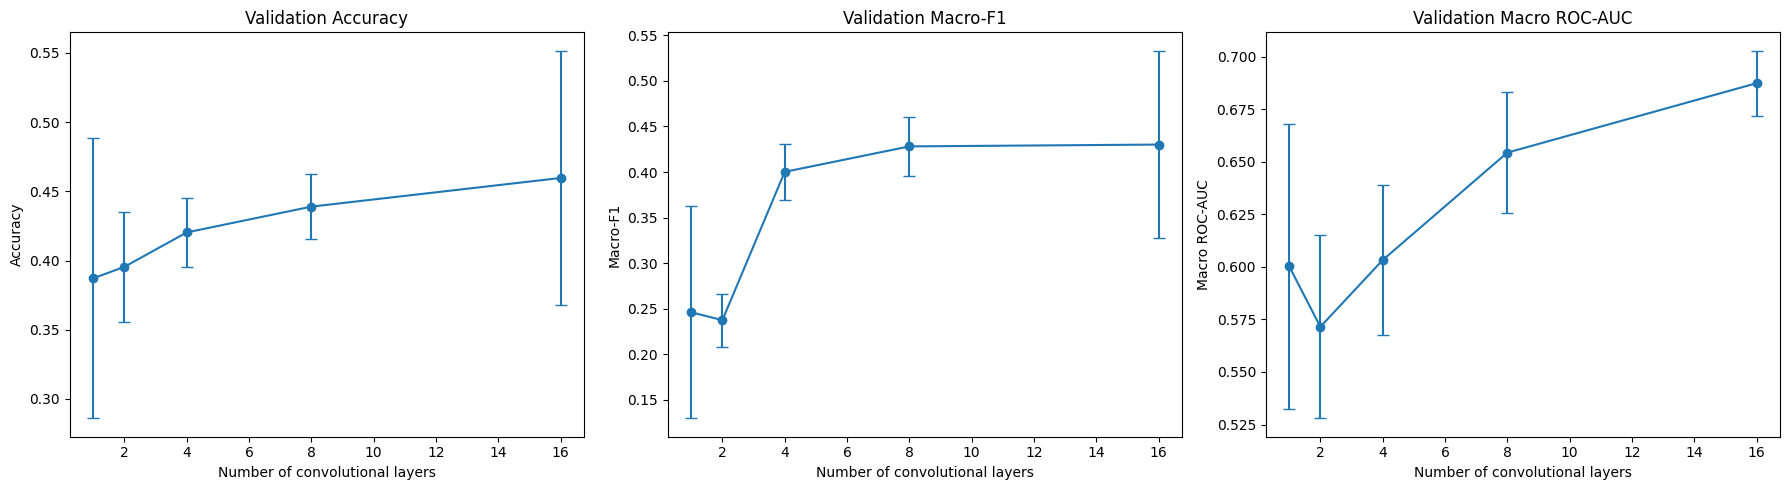

In [ ]:
# ANALYSE DEPTH SWEEP RESULTS

print("Columns in depth_results_df:")
print(depth_results_df.columns.tolist())

# Make sure the convolution-depth column has the expected name.
# The sweep may have stored it under a different name.
if "n_conv_layers" not in depth_results_df.columns:
    possible_depth_cols = [
        "depth",
        "conv_layers",
        "num_conv_layers",
        "n_layers",
        "layers"
    ]

    found_col = next(
        (c for c in possible_depth_cols if c in depth_results_df.columns),
        None
    )

    if found_col is not None:
        depth_results_df = depth_results_df.rename(
            columns={found_col: "n_conv_layers"}
        )
    else:
        raise KeyError(
            "Could not find the convolution-depth column. "
            f"Available columns are: {depth_results_df.columns.tolist()}"
        )

# Check that parameter count is available.
if "n_params" not in depth_results_df.columns:
    raise KeyError(
        f"'n_params' is missing from depth_results_df. "
        f"Available columns: {depth_results_df.columns.tolist()}"
    )

summary_df = (
    depth_results_df
    .groupby("n_conv_layers")
    .agg(
        n_params=("n_params", "first"),
        acc_mean=("accuracy", "mean"),
        acc_std=("accuracy", "std"),
        f1_mean=("macro_f1", "mean"),
        f1_std=("macro_f1", "std"),
        auc_mean=("macro_roc_auc", "mean"),
        auc_std=("macro_roc_auc", "std"),
    )
    .reset_index()
    .sort_values("n_conv_layers")
)

display(summary_df.round(4))

# ------------------------------------------------------------
# Select final depth using a pre-defined rule:
#   1. Highest mean Macro-F1
#   2. If tied, highest mean Macro-AUC
#   3. If still tied, choose the shallower network
# ------------------------------------------------------------

selection_df = summary_df.sort_values(
    by=["f1_mean", "auc_mean", "n_conv_layers"],
    ascending=[False, False, True]
)

CHOSEN_DEPTH = int(selection_df.iloc[0]["n_conv_layers"])

print("=" * 70)
print("DEPTH SELECTION")
print("=" * 70)
print(f"Selected convolutional depth: {CHOSEN_DEPTH} layers")
print(f"Mean Macro-F1:  {selection_df.iloc[0]['f1_mean']:.4f}")
print(f"Mean Macro-AUC: {selection_df.iloc[0]['auc_mean']:.4f}")
print("=" * 70)

# ------------------------------------------------------------
# Plot depth performance
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].errorbar(
    summary_df["n_conv_layers"],
    summary_df["acc_mean"],
    yerr=summary_df["acc_std"],
    marker="o",
    capsize=4
)
axes[0].set_xlabel("Number of convolutional layers")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Validation Accuracy")

axes[1].errorbar(
    summary_df["n_conv_layers"],
    summary_df["f1_mean"],
    yerr=summary_df["f1_std"],
    marker="o",
    capsize=4
)
axes[1].set_xlabel("Number of convolutional layers")
axes[1].set_ylabel("Macro-F1")
axes[1].set_title("Validation Macro-F1")

axes[2].errorbar(
    summary_df["n_conv_layers"],
    summary_df["auc_mean"],
    yerr=summary_df["auc_std"],
    marker="o",
    capsize=4
)
axes[2].set_xlabel("Number of convolutional layers")
axes[2].set_ylabel("Macro ROC-AUC")
axes[2].set_title("Validation Macro ROC-AUC")

plt.tight_layout()
plt.show()

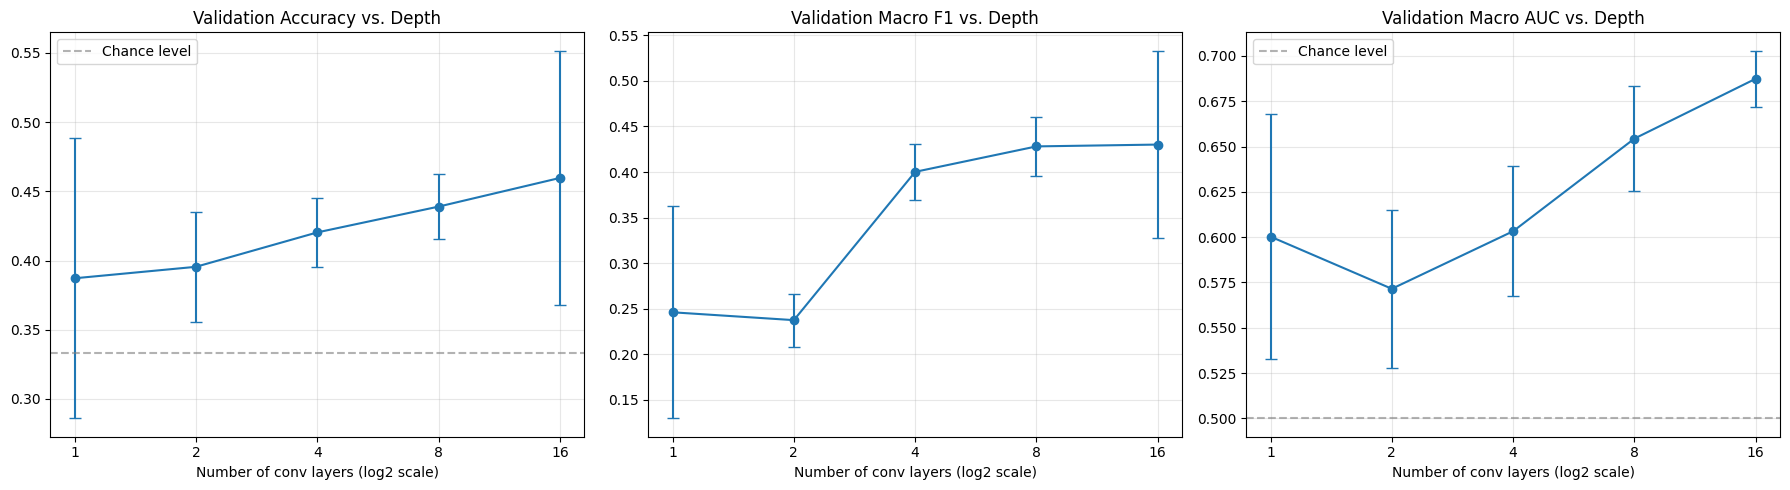

In [ ]:
import math
chance_loss = math.log(3)  # ~1.0986, reference line for "not learning"
chance_acc = 1/3

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_plot = [("acc_mean", "acc_std", chance_acc, "Validation Accuracy"),
                ("f1_mean", "f1_std", None, "Validation Macro F1"),
                ("auc_mean", "auc_std", 0.5, "Validation Macro AUC")]

for ax, (mean_col, std_col, baseline, title) in zip(axes, metrics_plot):
    ax.errorbar(summary_df["n_conv_layers"], summary_df[mean_col], yerr=summary_df[std_col],
                marker="o", capsize=4)
    if baseline is not None:
        ax.axhline(baseline, color="gray", linestyle="--", alpha=0.6, label="Chance level")
        ax.legend()
    ax.set_xscale("log", base=2)
    ax.set_xticks(DEPTHS_TO_TEST)
    ax.set_xticklabels(DEPTHS_TO_TEST)
    ax.set_xlabel("Number of conv layers (log2 scale)")
    ax.set_title(f"{title} vs. Depth")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The depth sweep showed increasing performance with model depth, with the 16-layer model achieving the highest mean Macro-AUC (0.687 ± 0.016) and slightly higher Macro-F1 (0.430 ± 0.103) compared with the 8-layer model (0.654 ± 0.029 AUC; 0.428 ± 0.032 F1). Therefore, the 16-layer configuration was selected for subsequent experiments.

In [ ]:
# ============================================================
# LOCK SELECTED MODEL DEPTH FOR ALL SUBSEQUENT EXPERIMENTS
# ============================================================

CHOSEN_DEPTH = 16

print("=" * 70)
print(f"CHOSEN_DEPTH locked at {CHOSEN_DEPTH} convolutional layers")
print("=" * 70)

CHOSEN_DEPTH locked at 16 convolutional layers


# 10. Augmentation experiments

After the depth sweep, the selected depth is fixed for all subsequent augmentation experiments.


In [ ]:
# ANALYSE DEPTH SWEEP + SELECT FINAL MODEL DEPTH

print("Depth results columns:")
print(depth_results_df.columns.tolist())

depth_summary_df = (
    depth_results_df
    .groupby("n_conv_layers")
    .agg(
        n_params=("n_params", "first"),
        acc_mean=("accuracy", "mean"),
        acc_std=("accuracy", "std"),
        f1_mean=("macro_f1", "mean"),
        f1_std=("macro_f1", "std"),
        auc_mean=("macro_roc_auc", "mean"),
        auc_std=("macro_roc_auc", "std")
    )
    .reset_index()
)

display(depth_summary_df.round(4))


# PRE-DECLARED DEPTH SELECTION RULE
#
# 1. Highest mean validation Macro-F1
# 2. Macro-AUC as tie-breaker
# 3. Shallower depth as final tie-breaker

best_depth_row = (
    depth_summary_df
    .sort_values(
        ["f1_mean", "auc_mean", "n_conv_layers"],
        ascending=[False, False, True]
    )
    .iloc[0]
)

CHOSEN_DEPTH = int(best_depth_row["n_conv_layers"])


print("=" * 70)
print("DEPTH SELECTION")
print("=" * 70)
print(f"Selected convolutional depth: {CHOSEN_DEPTH} layers")
print(f"Mean validation Macro-F1:     {best_depth_row['f1_mean']:.4f}")
print(f"Mean validation Macro-AUC:    {best_depth_row['auc_mean']:.4f}")
print("=" * 70)

Depth results columns:
['n_conv_layers', 'seed', 'n_params', 'best_epoch', 'best_val_loss', 'accuracy', 'macro_f1', 'macro_roc_auc', 'macro_ap']


,n_conv_layers,n_params,acc_mean,acc_std,f1_mean,f1_std,auc_mean,auc_std
0,1,123,0.3872,0.1012,0.2461,0.1163,0.6003,0.0677
1,2,723,0.3954,0.0399,0.2375,0.0292,0.5715,0.0436
2,4,4299,0.4203,0.0251,0.4002,0.0310,0.6033,0.0359
3,8,36987,0.4389,0.0235,0.4281,0.0319,0.6544,0.0288
4,16,111483,0.4596,0.0919,0.4301,0.1030,0.6874,0.0155


DEPTH SELECTION
Selected convolutional depth: 16 layers
Mean validation Macro-F1:     0.4301
Mean validation Macro-AUC:    0.6874


## 10A. Gaussian pixel perturbation


The existing result was not strong enough to justify expanding this search further. The more domain-informed Poisson/X-ray noise experiment below is the preferred final perturbation.

,sigma,acc_mean,acc_std,f1_mean,f1_std,auc_mean,auc_std
0,0.000,0.4596,0.0919,0.4301,0.1030,0.6874,0.0155
1,0.005,0.3892,0.0294,0.3613,0.0530,0.6313,0.0283
2,0.010,0.3789,0.0812,0.3214,0.1472,0.5929,0.0963
3,0.020,0.4058,0.0528,0.3828,0.0350,0.6348,0.0479
4,0.050,0.4389,0.0280,0.4240,0.0307,0.6582,0.0178


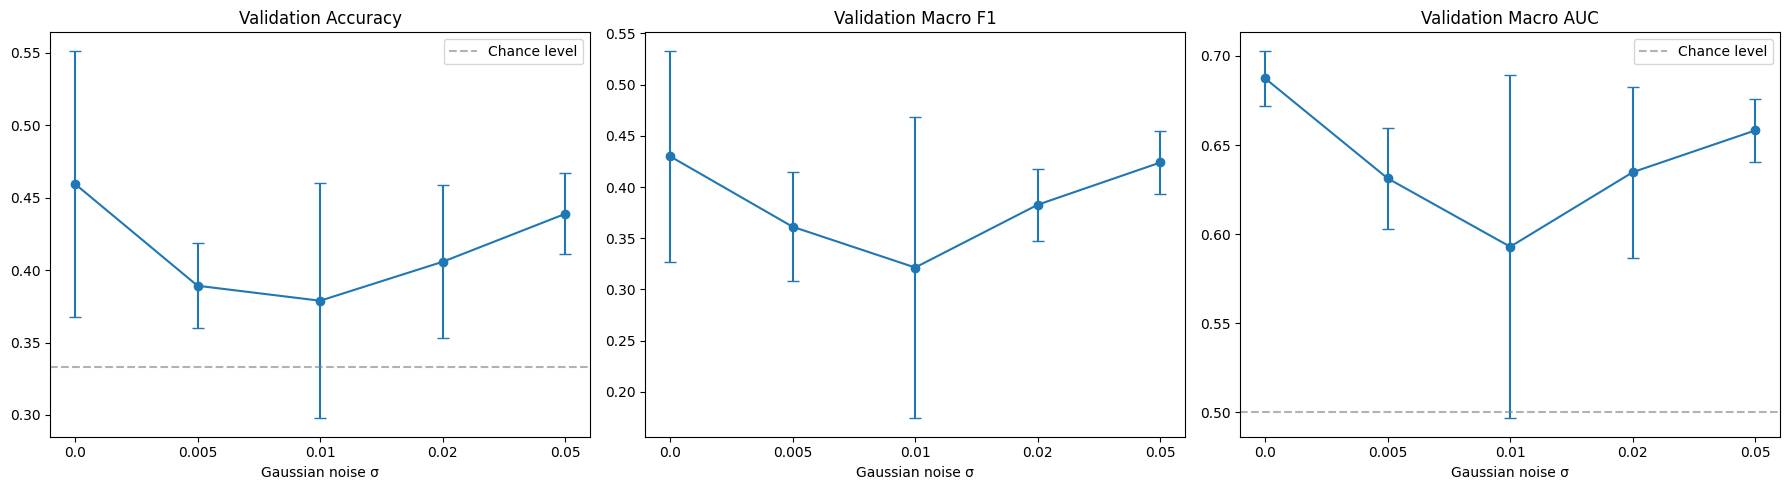

In [ ]:
RUN_GAUSSIAN_SWEEP = True

class GaussianPixelNoise:
    """Add N(0, sigma^2) noise to a [0,1] tensor, then clip."""
    def __init__(self, sigma):
        self.sigma = sigma

    def __call__(self, tensor):
        if self.sigma == 0:
            return tensor

        noise = torch.randn_like(tensor) * self.sigma
        return torch.clamp(
            tensor + noise,
            0.0,
            1.0
        )


def make_gaussian_noise_transform(sigma):
    return transforms.Compose([
        transforms.ToTensor(),
        GaussianPixelNoise(sigma),
        transforms.Normalize(
            mean=[train_mean],
            std=[train_std]
        )
    ])


if RUN_GAUSSIAN_SWEEP:

    gaussian_results = []

    for sigma in [0.0, 0.005, 0.01, 0.02, 0.05]:

        for seed in SEEDS_TO_TRY:

            set_all_seeds(seed)

            dataset = GOSHNECDataset(
                train_df,
                transform=make_gaussian_noise_transform(sigma)
            )

            loader = make_seeded_loader(
                dataset,
                seed
            )

            model = ConfigurableLightweightCNN(
                n_conv_layers=CHOSEN_DEPTH,
                num_classes=3
            ).to(device)

            criterion = nn.CrossEntropyLoss()

            optimizer = optim.AdamW(
                model.parameters(),
                lr=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY
            )

            training = train_model(
                model,
                loader,
                val_loader,
                criterion,
                optimizer,
                NUM_EPOCHS,
                PATIENCE,
                f"gaussian_sigma={sigma},seed={seed}"
            )

            metrics = compute_metrics(
                model,
                val_loader
            )

            gaussian_results.append({
                "sigma": sigma,
                "seed": seed,
                "best_epoch": training["best_epoch"],
                "best_val_loss": training["best_val_loss"],
                **metrics
            })

    gaussian_results_df = pd.DataFrame(
        gaussian_results
    )

    GAUSSIAN_RESULTS_PATH = (
    RESULTS_DIR / "gaussian_pixel_noise_reproducible.csv"
)

    gaussian_results_df.to_csv(
        GAUSSIAN_RESULTS_PATH,
        index=False
    )

    gaussian_summary_df = summarize_results(
        gaussian_results_df,
        "sigma"
    )

    display(gaussian_summary_df.round(4))
    plot_summary(
        gaussian_summary_df,
        "sigma",
        "Gaussian noise σ"
    )

else:
    print("Gaussian sweep skipped.")


## 10B. Geometric/intensity Transformation sweeps


In [ ]:
RUN_EXPLORATORY_GEOMETRIC_SWEEPS = False


def run_reproducible_sweep(
    values,
    parameter_name,
    transform_builder,
    results_path
):
    results = []

    for value in values:

        for seed in SEEDS_TO_TRY:

            print(
                f"\n{'='*70}\n"
                f"{parameter_name}={value}, seed={seed}\n"
                f"{'='*70}"
            )

            set_all_seeds(seed)

            dataset = GOSHNECDataset(
                train_df,
                transform=transform_builder(value)
            )

            loader = make_seeded_loader(
                dataset,
                seed
            )

            model = ConfigurableLightweightCNN(
                n_conv_layers=CHOSEN_DEPTH,
                num_classes=3
            ).to(device)

            criterion = nn.CrossEntropyLoss()

            optimizer = optim.AdamW(
                model.parameters(),
                lr=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY
            )

            training = train_model(
                model,
                loader,
                val_loader,
                criterion,
                optimizer,
                NUM_EPOCHS,
                PATIENCE,
                f"{parameter_name}={value},seed={seed}"
            )

            metrics = compute_metrics(
                model,
                val_loader
            )

            results.append({
                parameter_name: value,
                "seed": seed,
                "best_epoch": training["best_epoch"],
                "best_val_loss": training["best_val_loss"],
                **metrics
            })

    results_df = pd.DataFrame(results)

    results_df.to_csv(
        results_path,
        index=False
    )

    summary_df = summarize_results(
        results_df,
        parameter_name
    )

    display(summary_df.round(4))
    plot_summary(
        summary_df,
        parameter_name,
        parameter_name
    )

    return results_df, summary_df


def make_translation_transform(frac):
    if frac == 0.0:
        return build_pil_transform(None)

    return build_pil_transform(
        transforms.RandomAffine(
            degrees=0,
            translate=(frac, frac),
            fill=0
        )
    )


def make_rotation_transform(degrees):
    if degrees == 0:
        return build_pil_transform(None)

    return build_pil_transform(
        transforms.RandomRotation(
            degrees=degrees,
            fill=0
        )
    )


def make_sharpness_transform(factor):
    if factor == 1.0:
        return build_pil_transform(None)

    return build_pil_transform(
        transforms.RandomAdjustSharpness(
            sharpness_factor=factor,
            p=1.0
        )
    )


def make_equalize_transform(probability):
    if probability == 0.0:
        return build_pil_transform(None)

    return build_pil_transform(
        transforms.RandomEqualize(
            p=probability
        )
    )


if RUN_EXPLORATORY_GEOMETRIC_SWEEPS:

    translation_results_df, translation_summary_df = run_reproducible_sweep(
        [0.0, 0.05, 0.10, 0.15],
        "translate_frac",
        make_translation_transform,
        RESULTS_DIR / "translation_reproducible.csv"
    )

    rotation_results_df, rotation_summary_df = run_reproducible_sweep(
        [0, 5, 10, 15],
        "rotation_deg",
        make_rotation_transform,
        RESULTS_DIR / "rotation_reproducible.csv"
    )

    sharpness_results_df, sharpness_summary_df = run_reproducible_sweep(
        [1.0, 1.5, 2.5, 4.0],
        "sharpness_factor",
        make_sharpness_transform,
        RESULTS_DIR / "sharpness_reproducible.csv"
    )

    equalize_results_df, equalize_summary_df = run_reproducible_sweep(
        [0.0, 0.3, 0.6, 1.0],
        "equalize_prob",
        make_equalize_transform,
        RESULTS_DIR / "equalization_reproducible.csv"
    )

    combo_results = []

    for translate_frac, rotation_deg in [
        (0.0, 0),
        (0.05, 10),
        (0.15, 10),
        (0.05, 5),
        (0.15, 5),
    ]:

        for seed in SEEDS_TO_TRY:

            set_all_seeds(seed)

            dataset = GOSHNECDataset(
                train_df,
                transform=build_pil_transform(
                    transforms.RandomAffine(
                        degrees=rotation_deg,
                        translate=(translate_frac, translate_frac),
                        fill=0
                    )
                    if translate_frac != 0.0 or rotation_deg != 0
                    else None
                )
            )

            loader = make_seeded_loader(
                dataset,
                seed
            )

            model = ConfigurableLightweightCNN(
                n_conv_layers=CHOSEN_DEPTH,
                num_classes=3
            ).to(device)

            criterion = nn.CrossEntropyLoss()

            optimizer = optim.AdamW(
                model.parameters(),
                lr=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY
            )

            label = f"t={translate_frac},r={rotation_deg}"

            training = train_model(
                model,
                loader,
                val_loader,
                criterion,
                optimizer,
                NUM_EPOCHS,
                PATIENCE,
                f"{label},seed={seed}"
            )

            metrics = compute_metrics(
                model,
                val_loader
            )

            combo_results.append({
                "translate_frac": translate_frac,
                "rotation_deg": rotation_deg,
                "combo_label": label,
                "seed": seed,
                "best_epoch": training["best_epoch"],
                "best_val_loss": training["best_val_loss"],
                **metrics
            })

    combo_results_df = pd.DataFrame(combo_results)

   combo_results_df.to_csv(
    RESULTS_DIR / "translation_rotation_reproducible.csv",
    index=False
)

    combo_summary_df = summarize_results(
        combo_results_df,
        "combo_label"
    )

    display(combo_summary_df.round(4))
    plot_summary(
        combo_summary_df,
        "combo_label",
        "Translation + rotation"
    )

else:
    print("Exploratory geometric/intensity sweeps skipped.")


Exploratory geometric/intensity sweeps skipped.


## 10C. Final geometric + intensity candidates

These candidates are the small set motivated by the earlier individual sweeps:

- baseline
- rotation 5° + sharpening 1.5×
- rotation 10° + sharpening 1.5×
- translation 5% + rotation 5° + sharpening 1.5×

The same three seeds are used for every candidate.


baseline, seed=42

baseline, seed=123

baseline, seed=7

rotation_5_sharpness_1.5, seed=42

rotation_5_sharpness_1.5, seed=123

rotation_5_sharpness_1.5, seed=7

rotation_10_sharpness_1.5, seed=42

rotation_10_sharpness_1.5, seed=123

rotation_10_sharpness_1.5, seed=7

translation_5_rotation_5_sharpness_1.5, seed=42

translation_5_rotation_5_sharpness_1.5, seed=123

translation_5_rotation_5_sharpness_1.5, seed=7


,label,translate_frac,rotation_deg,sharpness_factor,seed,best_epoch,best_val_loss,accuracy,macro_f1,macro_roc_auc,macro_ap
0,baseline,0.00,0,1.0,42,22,1.0003,0.5031,0.4618,0.6925,0.5127
1,baseline,0.00,0,1.0,123,15,0.9843,0.5217,0.5135,0.6997,0.5306
2,baseline,0.00,0,1.0,7,10,1.0734,0.3540,0.3150,0.6701,0.5068
3,rotation_5_sharpness_1.5,0.00,5,1.5,42,9,1.0362,0.4224,0.4118,0.6719,0.5355
4,rotation_5_sharpness_1.5,0.00,5,1.5,123,10,1.0540,0.4224,0.4179,0.6385,0.4796
5,rotation_5_sharpness_1.5,0.00,5,1.5,7,29,0.8880,0.5590,0.5540,0.7815,0.6278
6,rotation_10_sharpness_1.5,0.00,10,1.5,42,11,1.0711,0.3975,0.3458,0.5908,0.4482
7,rotation_10_sharpness_1.5,0.00,10,1.5,123,13,1.0372,0.4534,0.4346,0.6513,0.4374
8,rotation_10_sharpness_1.5,0.00,10,1.5,7,1,1.0790,0.3789,0.3296,0.6186,0.4461
9,translation_5_rotation_5_sharpness_1.5,0.05,5,1.5,42,9,1.0700,0.3975,0.3966,0.6065,0.4391


,label,acc_mean,acc_std,f1_mean,f1_std,auc_mean,auc_std
0,baseline,0.4596,0.0919,0.4301,0.1030,0.6874,0.0155
1,rotation_10_sharpness_1.5,0.4099,0.0388,0.3700,0.0565,0.6202,0.0303
2,rotation_5_sharpness_1.5,0.4679,0.0789,0.4612,0.0804,0.6973,0.0748
3,translation_5_rotation_5_sharpness_1.5,0.4617,0.0725,0.4588,0.0702,0.6479,0.0431


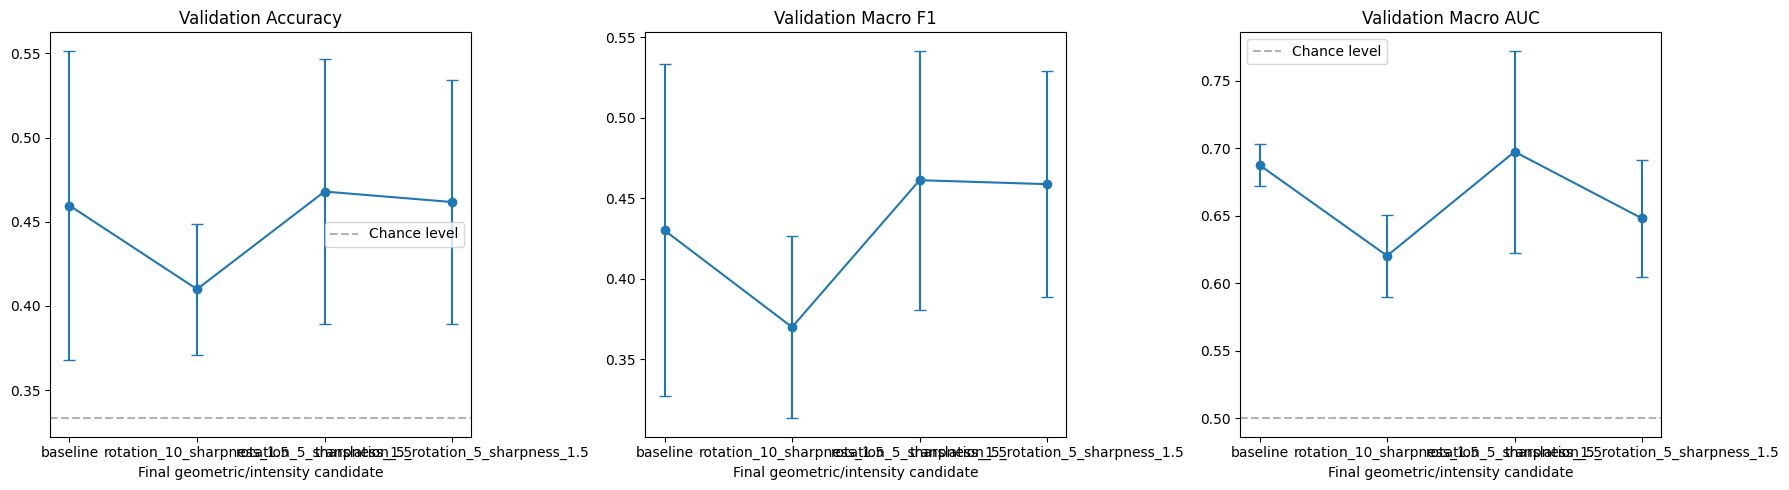

Saved: /content/drive/MyDrive/CHOC/checkpoints/final_geometric_reproducible.csv


In [ ]:
FINAL_GEOMETRIC_CANDIDATES = [
    {
        "label": "baseline",
        "translate_frac": 0.00,
        "rotation_deg": 0,
        "sharpness_factor": 1.0
    },
    {
        "label": "rotation_5_sharpness_1.5",
        "translate_frac": 0.00,
        "rotation_deg": 5,
        "sharpness_factor": 1.5
    },
    {
        "label": "rotation_10_sharpness_1.5",
        "translate_frac": 0.00,
        "rotation_deg": 10,
        "sharpness_factor": 1.5
    },
    {
        "label": "translation_5_rotation_5_sharpness_1.5",
        "translate_frac": 0.05,
        "rotation_deg": 5,
        "sharpness_factor": 1.5
    }
]


def make_geometric_intensity_transform(config):
    ops = []

    if (
        config["translate_frac"] != 0.0
        or config["rotation_deg"] != 0
    ):
        ops.append(
            transforms.RandomAffine(
                degrees=config["rotation_deg"],
                translate=(
                    config["translate_frac"],
                    config["translate_frac"]
                ),
                fill=0
            )
        )

    if config["sharpness_factor"] != 1.0:
        ops.append(
            transforms.RandomAdjustSharpness(
                sharpness_factor=config["sharpness_factor"],
                p=1.0
            )
        )

    ops.extend([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[train_mean],
            std=[train_std]
        )
    ])

    return transforms.Compose(ops)


final_geometric_results = []

for config in FINAL_GEOMETRIC_CANDIDATES:

    for seed in SEEDS_TO_TRY:

        print(
            f"\n{'='*70}\n"
            f"{config['label']}, seed={seed}\n"
            f"{'='*70}"
        )

        set_all_seeds(seed)

        dataset = GOSHNECDataset(
            train_df,
            transform=make_geometric_intensity_transform(config)
        )

        loader = make_seeded_loader(
            dataset,
            seed
        )

        model = ConfigurableLightweightCNN(
            n_conv_layers=CHOSEN_DEPTH,
            num_classes=3
        ).to(device)

        criterion = nn.CrossEntropyLoss()

        optimizer = optim.AdamW(
            model.parameters(),
            lr=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY
        )

        training = train_model(
            model,
            loader,
            val_loader,
            criterion,
            optimizer,
            NUM_EPOCHS,
            PATIENCE,
            f"{config['label']},seed={seed}"
        )

        metrics = compute_metrics(
            model,
            val_loader
        )

        final_geometric_results.append({
            **config,
            "seed": seed,
            "best_epoch": training["best_epoch"],
            "best_val_loss": training["best_val_loss"],
            **metrics
        })


final_geometric_results_df = pd.DataFrame(
    final_geometric_results
)

FINAL_GEOMETRIC_RESULTS_PATH = (
    RESULTS_DIR / "final_geometric_reproducible.csv"
)

final_geometric_results_df.to_csv(
    FINAL_GEOMETRIC_RESULTS_PATH,
    index=False
)

final_geometric_summary_df = summarize_results(
    final_geometric_results_df,
    "label"
)

display(
    final_geometric_results_df.round(4)
)

display(
    final_geometric_summary_df.round(4)
)

plot_summary(
    final_geometric_summary_df,
    "label",
    "Final geometric/intensity candidate"
)

print(
    "Saved:",
    FINAL_GEOMETRIC_RESULTS_PATH
)


# 11. Physics-informed X-ray augmentation

We model signal-dependent photon-counting noise with a Poisson distribution:

**N ~ Poisson(I × S)**

where `I` is normalized image intensity in [0, 1] and `S` is the photon-count scale. Lower `S` produces stronger relative noise; higher `S` produces weaker noise.



physics scale=None, seed=42

physics scale=None, seed=123

physics scale=None, seed=7

physics scale=500, seed=42

physics scale=500, seed=123

physics scale=500, seed=7

physics scale=1000, seed=42

physics scale=1000, seed=123

physics scale=1000, seed=7

physics scale=2000, seed=42

physics scale=2000, seed=123

physics scale=2000, seed=7

physics scale=5000, seed=42

physics scale=5000, seed=123

physics scale=5000, seed=7


,photon_scale,seed,best_epoch,best_val_loss,accuracy,macro_f1,macro_roc_auc,macro_ap
0,baseline,42,22,1.0003,0.5031,0.4618,0.6925,0.5127
1,baseline,123,15,0.9843,0.5217,0.5135,0.6997,0.5306
2,baseline,7,10,1.0734,0.3540,0.3150,0.6701,0.5068
3,500,42,4,1.0923,0.4161,0.3206,0.5741,0.4074
4,500,123,15,1.0269,0.4658,0.4723,0.6683,0.5136
5,500,7,4,1.0789,0.3975,0.3764,0.5999,0.4252
6,1000,42,16,1.0046,0.4783,0.4735,0.6943,0.5252
7,1000,123,5,1.0822,0.3230,0.2905,0.5836,0.4147
8,1000,7,14,1.0029,0.4348,0.4329,0.7049,0.5439
9,2000,42,4,1.0996,0.2919,0.2586,0.6115,0.4677


,photon_scale,acc_mean,acc_std,f1_mean,f1_std,auc_mean,auc_std
0,500,0.4265,0.0353,0.3898,0.0767,0.6141,0.0487
1,1000,0.4120,0.0801,0.3990,0.0961,0.6609,0.0672
2,2000,0.3375,0.0502,0.2949,0.0458,0.6097,0.0519
3,5000,0.3934,0.0827,0.3527,0.1449,0.5984,0.0563
4,baseline,0.4596,0.0919,0.4301,0.1030,0.6874,0.0155


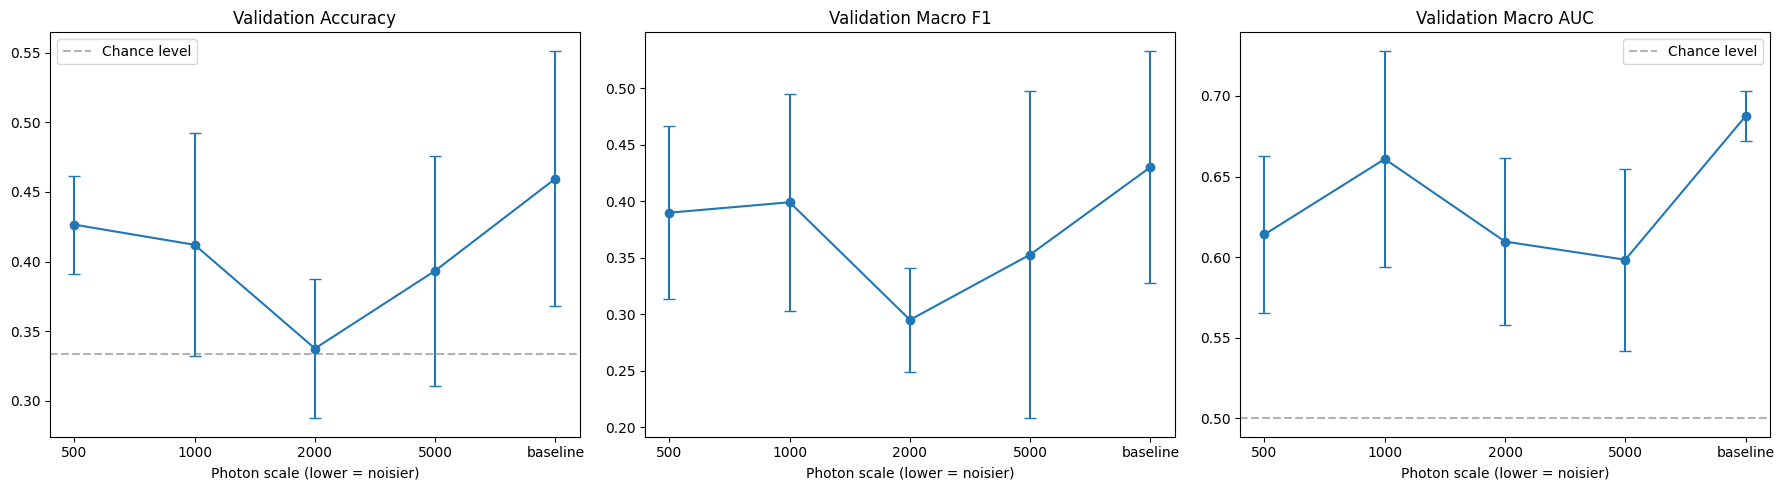

Saved: /content/drive/MyDrive/CHOC/checkpoints/physics_noise_reproducible.csv


In [ ]:
class PhysicsBasedXRayNoise:
    """
    Signal-dependent Poisson photon-counting noise.

    Input tensor must be in [0, 1].
    Higher photon_scale -> weaker relative noise.
    Lower photon_scale  -> stronger relative noise.
    """
    def __init__(self, photon_scale):
        self.photon_scale = photon_scale

    def __call__(self, tensor):

        if self.photon_scale is None:
            return tensor

        photon_counts = tensor * self.photon_scale

        noisy_counts = torch.poisson(
            photon_counts
        )

        noisy = noisy_counts / self.photon_scale

        return torch.clamp(
            noisy,
            0.0,
            1.0
        )


def make_physics_transform(photon_scale):
    return transforms.Compose([
        transforms.ToTensor(),
        PhysicsBasedXRayNoise(photon_scale),
        transforms.Normalize(
            mean=[train_mean],
            std=[train_std]
        )
    ])


PHYSICS_SCALES = [
    None,
    500,
    1000,
    2000,
    5000
]


physics_results = []

for scale in PHYSICS_SCALES:

    for seed in SEEDS_TO_TRY:

        print(
            f"\n{'='*70}\n"
            f"physics scale={scale}, seed={seed}\n"
            f"{'='*70}"
        )

        set_all_seeds(seed)

        dataset = GOSHNECDataset(
            train_df,
            transform=make_physics_transform(scale)
        )

        loader = make_seeded_loader(
            dataset,
            seed
        )

        model = ConfigurableLightweightCNN(
            n_conv_layers=CHOSEN_DEPTH,
            num_classes=3
        ).to(device)

        criterion = nn.CrossEntropyLoss()

        optimizer = optim.AdamW(
            model.parameters(),
            lr=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY
        )

        training = train_model(
            model,
            loader,
            val_loader,
            criterion,
            optimizer,
            NUM_EPOCHS,
            PATIENCE,
            f"physics_scale={scale},seed={seed}"
        )

        metrics = compute_metrics(
            model,
            val_loader
        )

        physics_results.append({
            "photon_scale": (
                scale if scale is not None else "baseline"
            ),
            "seed": seed,
            "best_epoch": training["best_epoch"],
            "best_val_loss": training["best_val_loss"],
            **metrics
        })


physics_results_df = pd.DataFrame(
    physics_results
)

PHYSICS_RESULTS_PATH = (
   RESULTS_DIR / "physics_noise_sweep_results.csv"
)

physics_results_df.to_csv(
    PHYSICS_RESULTS_PATH,
    index=False
)

physics_summary_df = summarize_results(
    physics_results_df,
    "photon_scale"
)

display(
    physics_results_df.round(4)
)

display(
    physics_summary_df.round(4)
)

plot_summary(
    physics_summary_df,
    "photon_scale",
    "Photon scale (lower = noisier)"
)

print("Saved:", PHYSICS_RESULTS_PATH)


# 12. Final hybrid experiment

The final validation experiment compares the best geometric/intensity candidate, the best physics setting, and their combination. The baseline is included again as an anchor.

**Stopping rule:** if the hybrid does not clearly improve Macro-F1/AUC over a simpler candidate, keep the simpler candidate and stop adding augmentations.


Best geometric/intensity candidate: rotation_5_sharpness_1.5
Best physics photon scale: 1000

baseline, seed=42

baseline, seed=123

baseline, seed=7

rotation_5_sharpness_1.5, seed=42

rotation_5_sharpness_1.5, seed=123

rotation_5_sharpness_1.5, seed=7

physics_1000, seed=42

physics_1000, seed=123

physics_1000, seed=7

rotation_5_sharpness_1.5_plus_physics_1000, seed=42

rotation_5_sharpness_1.5_plus_physics_1000, seed=123

rotation_5_sharpness_1.5_plus_physics_1000, seed=7


,label,seed,best_epoch,best_val_loss,accuracy,macro_f1,macro_roc_auc,macro_ap
0,baseline,42,22,1.0003,0.5031,0.4618,0.6925,0.5127
1,baseline,123,15,0.9843,0.5217,0.5135,0.6997,0.5306
2,baseline,7,10,1.0734,0.3540,0.3150,0.6701,0.5068
3,rotation_5_sharpness_1.5,42,9,1.0362,0.4224,0.4118,0.6719,0.5355
4,rotation_5_sharpness_1.5,123,10,1.0540,0.4224,0.4179,0.6385,0.4796
5,rotation_5_sharpness_1.5,7,29,0.8880,0.5590,0.5540,0.7815,0.6278
6,physics_1000,42,16,1.0046,0.4783,0.4735,0.6943,0.5252
7,physics_1000,123,5,1.0822,0.3230,0.2905,0.5836,0.4147
8,physics_1000,7,14,1.0029,0.4348,0.4329,0.7049,0.5439
9,rotation_5_sharpness_1.5_plus_physics_1000,42,18,0.9277,0.5155,0.5135,0.7315,0.5637


,label,acc_mean,acc_std,f1_mean,f1_std,auc_mean,auc_std
0,baseline,0.4596,0.0919,0.4301,0.1030,0.6874,0.0155
1,physics_1000,0.4120,0.0801,0.3990,0.0961,0.6609,0.0672
2,rotation_5_sharpness_1.5,0.4679,0.0789,0.4612,0.0804,0.6973,0.0748
3,rotation_5_sharpness_1.5_plus_physics_1000,0.3913,0.1274,0.3776,0.1505,0.5888,0.1397


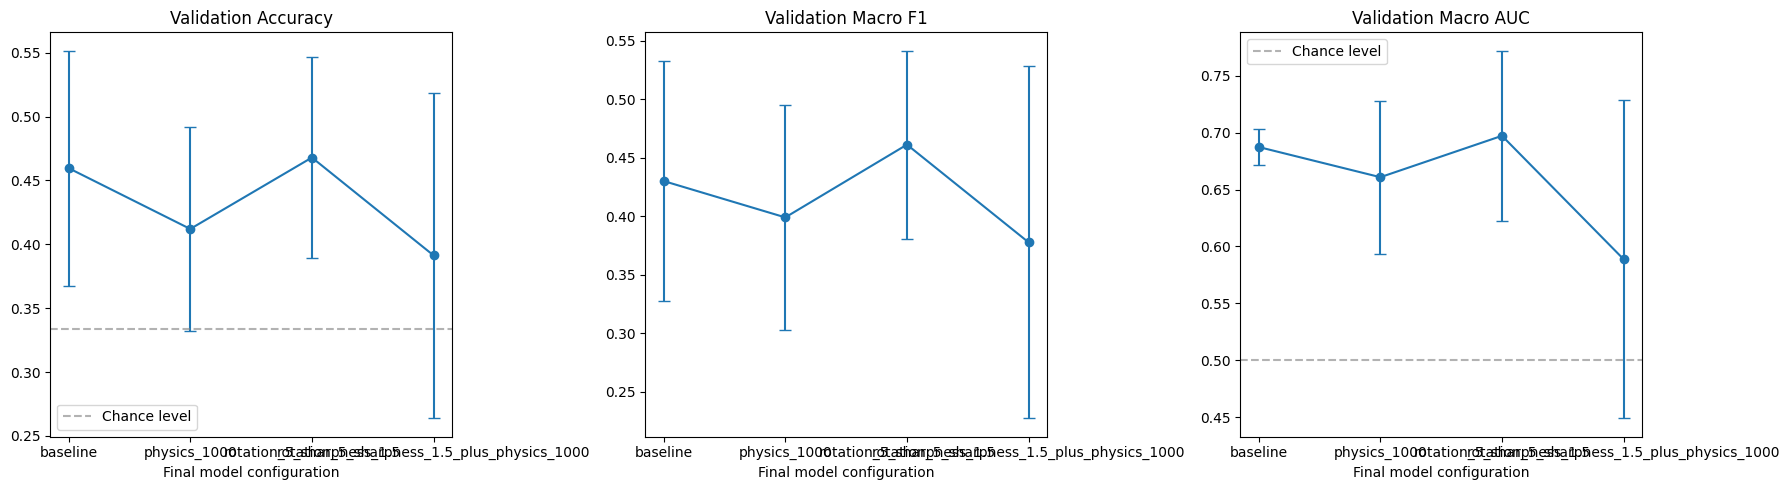

Saved: /content/drive/MyDrive/CHOC/checkpoints/final_hybrid_augmentation_results.csv


In [ ]:
# ------------------------------------------------------------
# Select best geometric candidate
# ------------------------------------------------------------

geometric_nonbaseline = final_geometric_summary_df[
    final_geometric_summary_df["label"] != "baseline"
].copy()

best_geometric_row = (
    geometric_nonbaseline
    .sort_values(
        ["f1_mean", "auc_mean"],
        ascending=False
    )
    .iloc[0]
)

best_geometric_label = best_geometric_row["label"]

best_geometric_config = next(
    c for c in FINAL_GEOMETRIC_CANDIDATES
    if c["label"] == best_geometric_label
)


# ------------------------------------------------------------
# Select best physics setting
# ------------------------------------------------------------

physics_nonbaseline = physics_summary_df[
    physics_summary_df["photon_scale"] != "baseline"
].copy()

best_physics_row = (
    physics_nonbaseline
    .sort_values(
        ["f1_mean", "auc_mean"],
        ascending=False
    )
    .iloc[0]
)

best_physics_scale = int(
    best_physics_row["photon_scale"]
)


print(
    "Best geometric/intensity candidate:",
    best_geometric_label
)
print(
    "Best physics photon scale:",
    best_physics_scale
)


# ------------------------------------------------------------
# Hybrid transform
# ------------------------------------------------------------

def make_hybrid_transform(
    geometric_config,
    photon_scale
):
    ops = []

    if (
        geometric_config["translate_frac"] != 0.0
        or geometric_config["rotation_deg"] != 0
    ):
        ops.append(
            transforms.RandomAffine(
                degrees=geometric_config["rotation_deg"],
                translate=(
                    geometric_config["translate_frac"],
                    geometric_config["translate_frac"]
                ),
                fill=0
            )
        )

    if geometric_config["sharpness_factor"] != 1.0:
        ops.append(
            transforms.RandomAdjustSharpness(
                sharpness_factor=geometric_config["sharpness_factor"],
                p=1.0
            )
        )

    ops.append(
        transforms.ToTensor()
    )

    ops.append(
        PhysicsBasedXRayNoise(
            photon_scale
        )
    )

    ops.append(
        transforms.Normalize(
            mean=[train_mean],
            std=[train_std]
        )
    )

    return transforms.Compose(ops)


HYBRID_CONFIGS = [
    {
        "label": "baseline",
        "geometric": {
            "translate_frac": 0.0,
            "rotation_deg": 0,
            "sharpness_factor": 1.0
        },
        "photon_scale": None
    },
    {
        "label": best_geometric_label,
        "geometric": best_geometric_config,
        "photon_scale": None
    },
    {
        "label": f"physics_{best_physics_scale}",
        "geometric": {
            "translate_frac": 0.0,
            "rotation_deg": 0,
            "sharpness_factor": 1.0
        },
        "photon_scale": best_physics_scale
    },
    {
        "label": (
            f"{best_geometric_label}"
            f"_plus_physics_{best_physics_scale}"
        ),
        "geometric": best_geometric_config,
        "photon_scale": best_physics_scale
    }
]


hybrid_results = []

for config in HYBRID_CONFIGS:

    for seed in SEEDS_TO_TRY:

        print(
            f"\n{'='*70}\n"
            f"{config['label']}, seed={seed}\n"
            f"{'='*70}"
        )

        set_all_seeds(seed)

        dataset = GOSHNECDataset(
            train_df,
            transform=make_hybrid_transform(
                config["geometric"],
                config["photon_scale"]
            )
        )

        loader = make_seeded_loader(
            dataset,
            seed
        )

        model = ConfigurableLightweightCNN(
            n_conv_layers=CHOSEN_DEPTH,
            num_classes=3
        ).to(device)

        criterion = nn.CrossEntropyLoss()

        optimizer = optim.AdamW(
            model.parameters(),
            lr=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY
        )

        training = train_model(
            model,
            loader,
            val_loader,
            criterion,
            optimizer,
            NUM_EPOCHS,
            PATIENCE,
            f"{config['label']},seed={seed}"
        )

        metrics = compute_metrics(
            model,
            val_loader
        )

        hybrid_results.append({
            "label": config["label"],
            "seed": seed,
            "best_epoch": training["best_epoch"],
            "best_val_loss": training["best_val_loss"],
            **metrics
        })


hybrid_results_df = pd.DataFrame(
    hybrid_results
)

HYBRID_RESULTS_PATH = (
    "/content/drive/MyDrive/CHOC/checkpoints/"
    "final_hybrid_augmentation_results.csv"
)

hybrid_results_df.to_csv(
    HYBRID_RESULTS_PATH,
    index=False
)

hybrid_summary_df = summarize_results(
    hybrid_results_df,
    "label"
)

display(
    hybrid_results_df.round(4)
)

display(
    hybrid_summary_df.round(4)
)

plot_summary(
    hybrid_summary_df,
    "label",
    "Final model configuration"
)

print(
    "Saved:",
    HYBRID_RESULTS_PATH
)


# 13. Per-class breakdown: confusion matrices

Macro-averaged metrics (used everywhere above) weight all three classes equally, which can hide
class-specific weaknesses -- particularly for **medical NEC (Mn)**, the smallest class (96 patients)
and, per the literature, the hardest of the three to distinguish reliably from imaging alone.

This section retrains **baseline** (no augmentation) and the **best geometric/intensity candidate**
selected above (`best_geometric_label`), across the same three seeds, at `CHOSEN_DEPTH`, using the
exact same `set_all_seeds` + `make_seeded_loader` protocol as every other experiment in this notebook.
Because that protocol is fully deterministic (seed set immediately before dataset/loader/model
construction, cuDNN forced deterministic), **re-running this cell will reproduce identical numbers**
to whatever you get the first time -- nothing here depends on what ran earlier in the session.

Confusion matrices are summed (raw counts) across the three seeds, since all three use the identical
locked validation set. Per-class precision/recall/F1 are reported as mean ± SD across seeds.


baseline, seed=42 (confusion-matrix pass)

baseline, seed=123 (confusion-matrix pass)

baseline, seed=7 (confusion-matrix pass)

rotation_5_sharpness_1.5, seed=42 (confusion-matrix pass)

rotation_5_sharpness_1.5, seed=123 (confusion-matrix pass)

rotation_5_sharpness_1.5, seed=7 (confusion-matrix pass)


,config,class,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,baseline,Medical NEC,0.4741,0.1558,0.5128,0.3525,0.4103,0.0890
1,baseline,No Pathology,0.4615,0.0129,0.5229,0.1306,0.4853,0.0665
2,baseline,Surgical NEC,0.5720,0.0575,0.3850,0.3009,0.3947,0.2734
3,rotation_5_sharpness_1.5,Medical NEC,0.4180,0.0275,0.7094,0.1502,0.5219,0.0525
4,rotation_5_sharpness_1.5,No Pathology,0.4697,0.1089,0.5229,0.0987,0.4817,0.0201
5,rotation_5_sharpness_1.5,Surgical NEC,0.5793,0.1005,0.2958,0.1842,0.3802,0.1788


Saved: /content/drive/MyDrive/CHOC/checkpoints/per_class_breakdown.csv


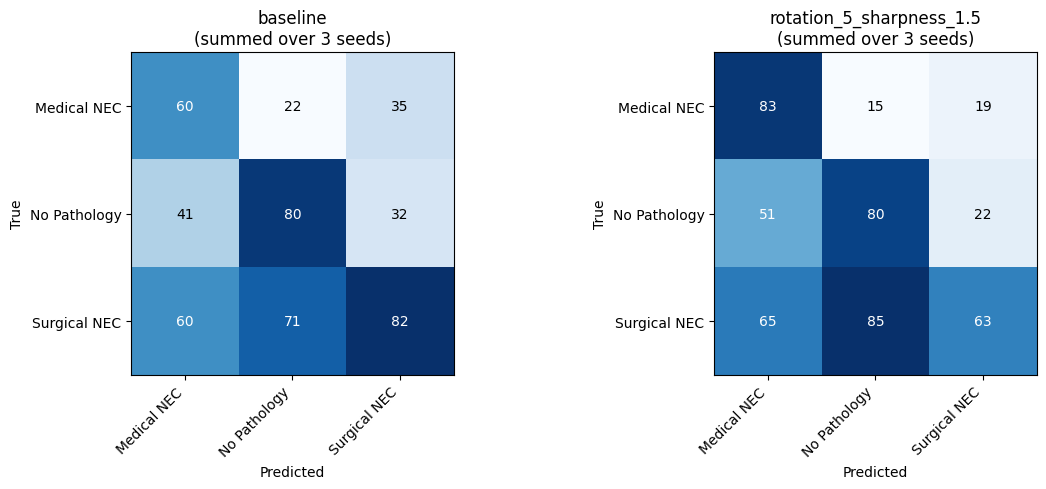

Saved: /content/drive/MyDrive/CHOC/checkpoints/confusion_matrices.png


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

CLASS_ORDER = ["Mn", "Np", "Sn"]  # matches LABEL_MAP order (0, 1, 2) used throughout
CLASS_DISPLAY = [CLASS_NAMES[c] for c in CLASS_ORDER]


def train_and_collect(geo_config, depth, seed):
    """Retrain one model under the exact seeded protocol used elsewhere in this notebook,
    then return validation predictions (not just aggregate metrics)."""
    set_all_seeds(seed)
    transform = make_geometric_intensity_transform(geo_config)
    dataset = GOSHNECDataset(train_df, transform=transform)
    loader = make_seeded_loader(dataset, seed)

    model = ConfigurableLightweightCNN(n_conv_layers=depth, num_classes=3).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    train_model(model, loader, val_loader, criterion, optimizer, NUM_EPOCHS, PATIENCE,
                f"confusion:{geo_config}:seed={seed}")

    y_true, y_pred, _ = collect_predictions(model, val_loader)
    return y_true, y_pred


BASELINE_GEOMETRIC_CONFIG = {"translate_frac": 0.0, "rotation_deg": 0, "sharpness_factor": 1.0}

CONFUSION_CONFIGS = [
    ("baseline", BASELINE_GEOMETRIC_CONFIG),
    (best_geometric_label, best_geometric_config),
]

confusion_matrices = {}
per_class_rows = []

for label, geo_config in CONFUSION_CONFIGS:
    summed_cm = np.zeros((3, 3), dtype=int)
    for seed in SEEDS_TO_TRY:
        print(f"\n{'='*70}\n{label}, seed={seed} (confusion-matrix pass)\n{'='*70}")
        y_true, y_pred = train_and_collect(geo_config, CHOSEN_DEPTH, seed)

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
        summed_cm += cm

        report = classification_report(y_true, y_pred, labels=[0, 1, 2],
                                        target_names=CLASS_DISPLAY,
                                        output_dict=True, zero_division=0)
        for cls in CLASS_DISPLAY:
            per_class_rows.append({
                "config": label, "seed": seed, "class": cls,
                "precision": report[cls]["precision"],
                "recall": report[cls]["recall"],
                "f1": report[cls]["f1-score"],
                "support": report[cls]["support"],
            })
    confusion_matrices[label] = summed_cm

per_class_df = pd.DataFrame(per_class_rows)
per_class_summary_df = (
    per_class_df.groupby(["config", "class"])
    .agg(precision_mean=("precision", "mean"), precision_std=("precision", "std"),
         recall_mean=("recall", "mean"), recall_std=("recall", "std"),
         f1_mean=("f1", "mean"), f1_std=("f1", "std"))
    .reset_index()
)
display(per_class_summary_df.round(4))

PER_CLASS_RESULTS_PATH = RESULTS_DIR / "per_class_breakdown.csv"
per_class_df.to_csv(PER_CLASS_RESULTS_PATH, index=False)
print("Saved:", PER_CLASS_RESULTS_PATH)

# --- Plot confusion matrices side by side ---
fig, axes = plt.subplots(1, len(CONFUSION_CONFIGS), figsize=(6 * len(CONFUSION_CONFIGS), 5))
if len(CONFUSION_CONFIGS) == 1:
    axes = [axes]

for ax, (label, _) in zip(axes, CONFUSION_CONFIGS):
    cm = confusion_matrices[label]
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_xticklabels(CLASS_DISPLAY, rotation=45, ha="right")
    ax.set_yticks(range(3)); ax.set_yticklabels(CLASS_DISPLAY)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{label}\n(summed over {len(SEEDS_TO_TRY)} seeds)")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
CONFUSION_PLOT_PATH = RESULTS_DIR / "confusion_matrices.png"
plt.savefig(CONFUSION_PLOT_PATH, dpi=150)
plt.show()
print("Saved:", CONFUSION_PLOT_PATH)

# 14. Reproducibility manifest


In [ ]:
manifest = {
    'dataset': 'GOSH NEC',
    'locked_test_patients': 100,
    'split_seed': SPLIT_SEED,
    'experiment_seeds': SEEDS_TO_TRY,
    'train_val_split': 'patient-level, approximately 80/20, stratified',
    'image_size': [TARGET_HEIGHT, TARGET_WIDTH],
    'batch_size': BATCH_SIZE,
    'epochs': NUM_EPOCHS,
    'early_stopping_patience': PATIENCE,
    'optimizer': 'AdamW',
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'depths_tested': DEPTHS_TO_TEST,
    'chosen_depth': CHOSEN_DEPTH,
    'selection_metric': 'mean validation Macro-F1, then Macro-AUC, then shallower depth',
    'locked_test_used_for_selection': False,
}
manifest_path = RESULTS_DIR / 'FINAL_experiment_manifest.json'
manifest_path.write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest, indent=2))
print('Saved:', manifest_path)
